In [1]:
!pip install --upgrade datasets

  Using cached datasets-4.4.2-py3-none-any.whl.metadata (19 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached datasets-4.4.2-py3-none-any.whl (512 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached anyio-4.12.0-py3-none-any.whl (113 kB)
  Attempting uninstall: datasets╺━━━━━━━━━━━━━━━ 3/5 [httpx]
    Found existing installation: datasets 3.1.0━━━━━━━━━━━━━━━ 3/5 [httpx]
    Uninstalling datasets-3.1.0:╺━━━━━━━━━━━━━━━ 3/5 [httpx]
      Successfully uninstalled datasets-3.1.00m━━━━━━━━━━━━━━━ 3/5 [httpx]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [datasets]4/5 [datasets]


In [21]:
from datasets import load_dataset, load_from_disk

dataset = load_from_disk("data/competition_math_with_steps_and_flags")

In [22]:
dataset["train"][500]

{'problem': 'A $100$-gon $P_1$ is drawn in the Cartesian plane.  The sum of the $x$-coordinates of the $100$ vertices equals 2009.  The midpoints of the sides of $P_1$ form a second $100$-gon, $P_2$.  Finally, the midpoints of the sides of $P_2$ form a third $100$-gon, $P_3$.  Find the sum of the $x$-coordinates of the vertices of $P_3$.',
 'level': 'Level 5',
 'type': 'Algebra',
 'solution': 'Let the $x$-coordinates of the vertices of $P_1$ be $x_1,x_2,\\ldots,x_{100}$.  Then, by the midpoint formula, the $x$-coordinates of the vertices of $P_2$ are $\\frac{x_1+x_2}2,\\frac{x_2+x_3}2,\\ldots,\\frac{x_{100}+x_1}2 $.  The sum of these equals $\\frac{2x_1+2x_2+\\cdots +2x_{100}}2=x_1+x_2+\\cdots+x_{100}$.  Similarly, the sum of the $x$-coordinates of the vertices of $P_3$ equals the sum of the $x$-coordinates of the vertices of  $P_2$.  Thus the desired answer is $\\boxed{2009}$.',
 'steps': ['Let the $x$-coordinates of the vertices of $P_1$ be $x_1,x_2,\\ldots,x_{100}$.',
  'Then, by th

In [23]:
dataset = dataset["train"]

In [24]:
import pandas as pd

df = pd.read_csv("data/full_classification_results.csv")

cls_map = {}

for _, row in df.iterrows():
    cls_map[row["problem"]] = [int(x) for x in row["difficulty_levels"].split(";")]

In [6]:
df.head()

,original_index,problem,problem_level,problem_type,original_steps,num_steps,step_texts,difficulty_levels,difficulty_names,explanations,...,level_1_pct,level_2_count,level_2_pct,level_3_count,level_3_pct,level_4_count,level_4_pct,hardest_level,easiest_level,avg_difficulty
0,0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"['For the piecewise function to be continuous,...",6,"For the piecewise function to be continuous, t...",2;2;2;2;2;2,Simple;Simple;Simple;Simple;Simple;Simple,This step involves directly applying the defin...,...,0.000000,6,100.000000,0,0.0,0,0.0,2,2,2.000000
1,1,A rectangular band formation is a formation wi...,Level 5,Algebra,['Let $x$ be the number of band members in eac...,8,Let $x$ be the number of band members in each ...,1;3;2;2;2;2;2;1,Trivial;Intermediate;Simple;Simple;Simple;Simp...,This step merely restates given information by...,...,25.000000,5,62.500000,1,12.5,0,0.0,3,1,1.875000
2,2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,['This polynomial is not written in standard f...,6,This polynomial is not written in standard for...,1;1;1;1;1;1,Trivial;Trivial;Trivial;Trivial;Trivial;Trivial,This step only involves recognizing that the p...,...,100.000000,0,0.000000,0,0.0,0,0.0,1,1,1.000000
3,3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"['Firstly, $3\\left(6-\\frac12\\right)=18-1-\\...",2,"Firstly, $3\\left(6-\\frac12\\right)=18-1-\\fr...",2;2,Simple;Simple,The step involves basic arithmetic operations ...,...,0.000000,2,100.000000,0,0.0,0,0.0,2,2,2.000000
4,4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,['Call $x$ the number of days Sam works and $y...,7,Call $x$ the number of days Sam works and $y$ ...,1;2;1;2;2;1;1,Trivial;Simple;Trivial;Simple;Simple;Trivial;T...,This step merely restates the given informatio...,...,57.142857,3,42.857143,0,0.0,0,0.0,2,1,1.428571


In [15]:
def extract_answer(solution):
    # extract answer in the form \\boxed{2009}, \\boxed{\\frac{4}{35}}, $x\\equiv -36 \\equiv \\boxed{9} \\pmod {45}$
    import re
    # Find the start of \\boxed{
    match = re.search(r"\\boxed\{", solution)
    if not match:
        return ""
    
    # Count braces to find the matching closing brace (handles nested braces)
    start = match.end()
    depth = 1
    i = start
    while i < len(solution) and depth > 0:
        if solution[i] == '{':
            depth += 1
        elif solution[i] == '}':
            depth -= 1
        i += 1
    
    if depth == 0:
        return solution[start:i-1]
    else:
        return ""

In [25]:
# Remove samples that have more than 15 steps
dataset = dataset.filter(lambda x: len(x["steps"]) <= 15)

# Add new columns using add_column
dataset = dataset.add_column("question", [item["problem"] for item in dataset])
dataset = dataset.add_column("answer", [extract_answer(item["solution"]) for item in dataset])
dataset = dataset.add_column("steps_difficulties", [cls_map.get(item["problem"], [1]*len(item["steps"])) for item in dataset])

# split into train, val and test
dataset = dataset.shuffle(seed=42)
train_size = int(0.95 * len(dataset))
val_size = int(0.01 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset = dataset.select(range(0, train_size))
val_dataset = dataset.select(range(train_size, train_size + val_size))
test_dataset = dataset.select(range(train_size + val_size, len(dataset)))

In [26]:
dataset[1023]

{'problem': 'A function $f$ is defined by $f(z) = i\\overline{z}$, where $i^2 = -1$ and $\\overline{z}$ is the complex conjugate of $z$. How many values of $z$ satisfy both $|z| = 5$ and $f(z) = z$?',
 'level': 'Level 3',
 'type': 'Intermediate Algebra',
 'solution': 'Let $z = x + yi,$ where $x$ and $y$ are real numbers.  Then $|z| = 5$ becomes $x^2 + y^2 = 25,$ and $f(z) = z$ becomes\n\\[i(x - yi) = x + yi.\\]Then $ix + y = x + yi,$ so $x = y.$\n\nHence, $2x^2 = 25,$ which has two solutions.  Thus, there are $\\boxed{2}$ such values of $z.$',
 'steps': ['Let $z = x + yi,$ where $x$ and $y$ are real numbers.',
  'Then $|z| = 5$ becomes $x^2 + y^2 = 25,$ and $f(z) = z$ becomes \\[i(x - yi) = x + yi.\\]Then $ix + y = x + yi,$ so $x = y.$ Hence, $2x^2 = 25,$ which has two solutions.',
  'Thus, there are $\\boxed{2}$ such values of $z.$'],
 'num_steps': 3,
 'split_flags': [],
 'split_warnings': [],
 'split_bad': False,
 'split_needs_resplit': False,
 'question': 'A function $f$ is defined 

In [27]:
train_dataset, val_dataset, test_dataset

(Dataset({
     features: ['problem', 'level', 'type', 'solution', 'steps', 'num_steps', 'split_flags', 'split_warnings', 'split_bad', 'split_needs_resplit', 'question', 'answer', 'steps_difficulties'],
     num_rows: 11330
 }),
 Dataset({
     features: ['problem', 'level', 'type', 'solution', 'steps', 'num_steps', 'split_flags', 'split_warnings', 'split_bad', 'split_needs_resplit', 'question', 'answer', 'steps_difficulties'],
     num_rows: 119
 }),
 Dataset({
     features: ['problem', 'level', 'type', 'solution', 'steps', 'num_steps', 'split_flags', 'split_warnings', 'split_bad', 'split_needs_resplit', 'question', 'answer', 'steps_difficulties'],
     num_rows: 478
 }))

In [29]:
difficulties = train_dataset["steps_difficulties"]

# stats
import numpy as np
all_difficulties = [d for sublist in difficulties for d in sublist]
print("Mean difficulty:", np.mean(all_difficulties))
print("Median difficulty:", np.median(all_difficulties))
print("Max difficulty:", np.max(all_difficulties))
print("Min difficulty:", np.min(all_difficulties))
print("Difficulty distribution:", {i: all_difficulties.count(i) for i in range(1, 6)})

Mean difficulty: 2.237318451742148
Median difficulty: 2.0
Max difficulty: 4
Min difficulty: 1
Difficulty distribution: {1: 9757, 2: 27280, 3: 14717, 4: 4154, 5: 0}


In [28]:
import json
import os

# Create directory if it doesn't exist
os.makedirs("data/math", exist_ok=True)

# save datasets as json files (array of objects)
with open("data/math/math_train.json", "w") as f:
    json.dump([item for item in train_dataset], f, indent=2)

with open("data/math/math_val.json", "w") as f:
    json.dump([item for item in val_dataset], f, indent=2)

with open("data/math/math_test.json", "w") as f:
    json.dump([item for item in test_dataset], f, indent=2)

In [10]:
from dataset import get_cot_latent_dataset, get_dataset
from transformers import AutoTokenizer
import yaml
from utils import Config

with open("configs/coconut/math_coconut_smollm2_135m.yaml") as f:
    config_dict = yaml.safe_load(f)

configs = Config(config_dict)

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.add_tokens("<|start-latent|>")
tokenizer.add_tokens("<|end-latent|>")
tokenizer.add_tokens("<|latent|>")
latent_id = tokenizer.convert_tokens_to_ids("<|latent|>")
start_id = tokenizer.convert_tokens_to_ids("<|start-latent|>")
end_id = tokenizer.convert_tokens_to_ids("<|end-latent|>")

base_dataset_train = get_dataset(
    "data/math/math_train.json", tokenizer, max_size=100000000
)

dataset_train = get_cot_latent_dataset(
    0,
    base_dataset_train,
    configs,
    start_id,
    latent_id,
    end_id,
    no_special_marker=configs.cot or configs.no_cot or configs.no_thoughts,
    shuffle=True,
)

Map (num_proc=32):   0%|          | 0/11330 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/11330 [00:00<?, ? examples/s]

In [12]:
import numpy as np
lengths = np.array([len(item["input_ids"]) for item in dataset_train])
np.mean(lengths), np.max(lengths), np.min(lengths)

(np.float64(290.0170344218888), np.int64(2480), np.int64(39))

In [13]:
!pip install seaborn

<Axes: ylabel='Count'>

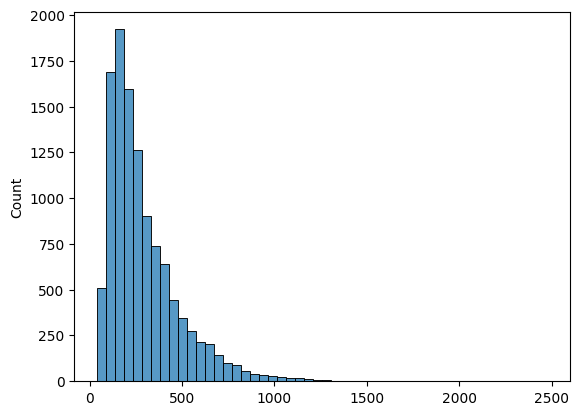

In [14]:
import seaborn as sns

sns.histplot(lengths, bins=50)

In [3]:
import json

with open("data/math/math_train.json") as f:
    train_data = json.load(f)

with open("data/math/math_val.json") as f:
    val_data = json.load(f)

with open("data/math/math_test.json") as f:
    test_data = json.load(f)

In [7]:
train_steps = [len(item["steps"]) for item in train_data]
val_steps = [len(item["steps"]) for item in val_data]
test_steps = [len(item["steps"]) for item in test_data]

sum(train_steps)/len(train_steps), sum(val_steps)/len(val_steps), sum(test_steps)/len(test_steps)

(4.4524271844660195, 4.336134453781512, 4.376569037656904)

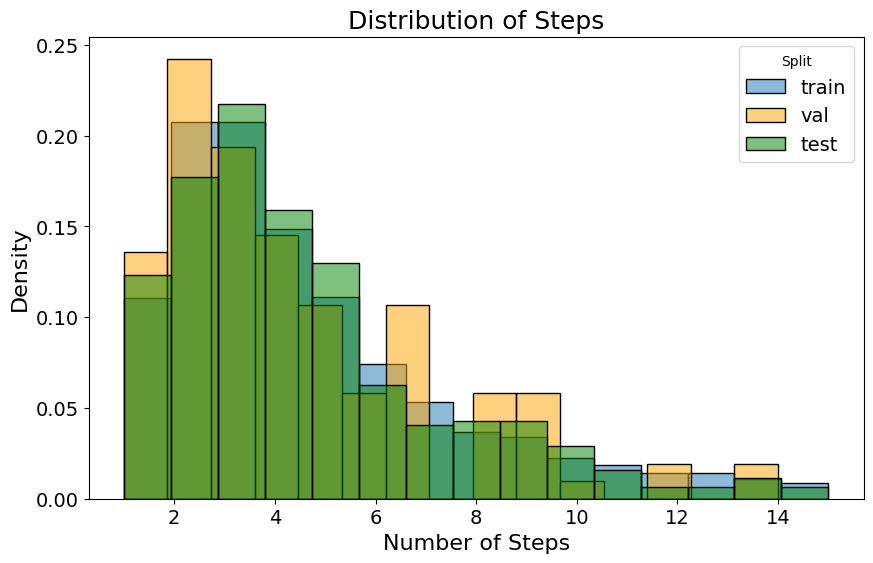

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(train_steps, bins=15, stat="density", label="train", alpha=0.5, ax=ax)
sns.histplot(val_steps, bins=15, stat="density", color="orange", label="val", alpha=0.5, ax=ax)
sns.histplot(test_steps, bins=15, stat="density", color="green", label="test", alpha=0.5, ax=ax)
ax.set_xlabel("Number of Steps", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_title("Distribution of Steps", fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(title="Split", fontsize=14)
fig.savefig("figures/math_steps_dist.pdf", bbox_inches='tight')
plt.show()

In [9]:
train_step_diffs = [sum(item["steps_difficulties"])/len(item["steps_difficulties"]) for item in train_data]
val_step_diffs = [sum(item["steps_difficulties"])/len(item["steps_difficulties"]) for item in val_data]
test_step_diffs = [sum(item["steps_difficulties"])/len(item["steps_difficulties"]) for item in test_data]

sum(train_step_diffs)/len(train_step_diffs), sum(val_step_diffs)/len(val_step_diffs), sum(test_step_diffs)/len(test_step_diffs)

(2.236323427709406, 2.2027511004401763, 2.2139522532539413)

In [10]:
all_train_step_diffs = [d for item in train_data for d in item["steps_difficulties"]]
all_val_step_diffs = [d for item in val_data for d in item["steps_difficulties"]]
all_test_step_diffs = [d for item in test_data for d in item["steps_difficulties"]]

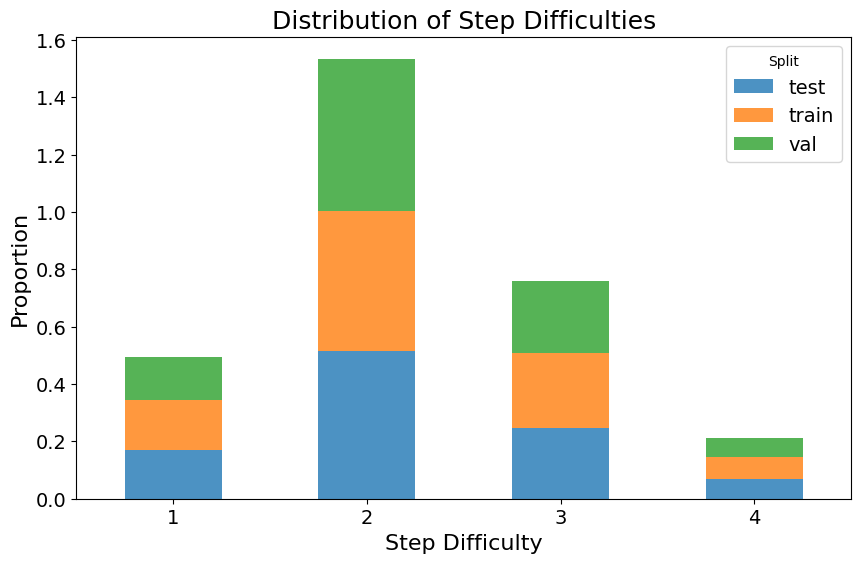

In [ ]:
import pandas as pd

# Create a DataFrame with step difficulties and their source
df = pd.DataFrame({
    'step_difficulty': all_train_step_diffs + all_val_step_diffs + all_test_step_diffs,
    'split': ['train'] * len(all_train_step_diffs) + ['val'] * len(all_val_step_diffs) + ['test'] * len(all_test_step_diffs)
})

# Count occurrences for each difficulty and split
counts = df.groupby(['step_difficulty', 'split']).size().unstack(fill_value=0)
# Normalize to get density
counts = counts.div(counts.sum())

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', stacked=True, ax=ax, alpha=0.8, color=['tab:blue', 'tab:orange', 'tab:green'])
ax.set_xlabel("Step Difficulty", fontsize=16)
ax.set_ylabel("Proportion", fontsize=16)
ax.set_title("Distribution of Step Difficulties", fontsize=18)
ax.legend(title="Split", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=0)
fig.savefig("figures/math_step_diffs_dist.pdf", bbox_inches='tight')
plt.show()

In [20]:
import json

with open("/mnt/scratch/home/ismayilz/project-dycoder/models/math-dycoder-qwen2.5-0.5b-e5-with-diff/latents_epoch_5.json") as f:
    pred_latents = json.load(f)

test_pred_steps = [len(latent_pred["latents"]) for latent_pred in pred_latents]
test_pred_diffs = [num_latents for latent_pred in pred_latents for num_latents in latent_pred["latents"]]

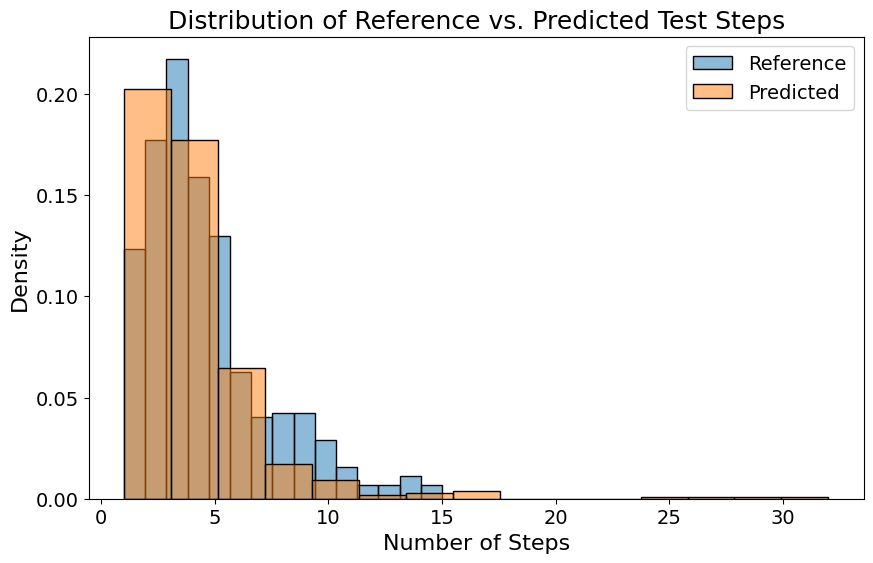

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(test_steps, bins=15, stat="density", label="Reference", alpha=0.5, ax=ax)
sns.histplot(test_pred_steps, bins=15, stat="density", label="Predicted", alpha=0.5, ax=ax)
ax.set_xlabel("Number of Steps", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_title("Distribution of Reference vs. Predicted Test Steps", fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14)
fig.savefig("figures/math_pred_steps_dist.pdf", bbox_inches='tight')
plt.show()

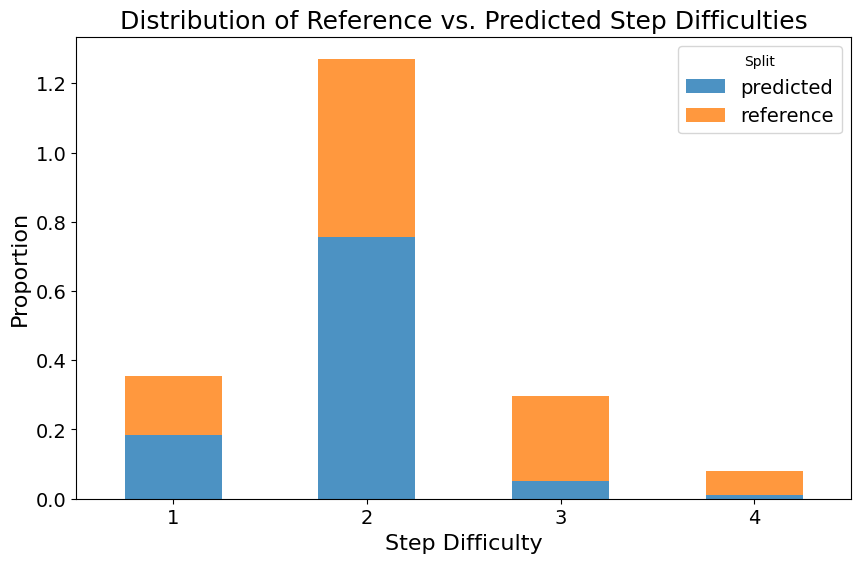

In [ ]:
import pandas as pd

# Create a DataFrame with step difficulties and their source
df = pd.DataFrame({
    'step_difficulty': all_test_step_diffs + test_pred_diffs,
    'split': ['reference'] * len(all_test_step_diffs) + ['predicted'] * len(test_pred_diffs)
})

# Count occurrences for each difficulty and split
counts = df.groupby(['step_difficulty', 'split']).size().unstack(fill_value=0)
# Normalize to get density
counts = counts.div(counts.sum())

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', stacked=True, ax=ax, alpha=0.8, color=['tab:blue', 'tab:orange'])
ax.set_xlabel("Step Difficulty", fontsize=16)
ax.set_ylabel("Proportion", fontsize=16)
ax.set_title("Distribution of Reference vs. Predicted Step Difficulties", fontsize=18)
ax.legend(fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=0)
fig.savefig("figures/math_pred_step_diffs_dist.pdf", bbox_inches='tight')
plt.show()